# 02 - Trajectory Reconstruction
Refocus this notebook on one job first: recover a clean gate-to-gate trajectory for a single flight, inspect it visually, and only then scale the same rules to the full ADS-B dataset.

## 1. Setup and Inputs


In [2]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import src.trajectory_builder as trajectory_builder_module
import src.visualisation as visualisation_module

trajectory_builder_module = importlib.reload(trajectory_builder_module)
visualisation_module = importlib.reload(visualisation_module)


PROJECT_ROOT = _resolve_project_root()
ctx = trajectory_builder_module.build_notebook_context(PROJECT_ROOT)


print(f'Project root: {ctx.project_root}')
print(f'ADS-B source: {ctx.adsb_input_path}')
print(f'Trajectory output: {ctx.traj_path}')
print(f'Default prototype seed: {ctx.seed}')

Project root: D:\Desertation\Code_v3\flight-disruption-prediction
ADS-B source: D:\Desertation\Code_v3\flight-disruption-prediction\data\processed\adsb_combined.parquet
Trajectory output: D:\Desertation\Code_v3\flight-disruption-prediction\data\processed\trajectories.parquet
Default prototype seed: 42


In [3]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.trajectory_builder import (
    PrototypeControls,
    PrototypeResult,
    TrajectoryNotebookContext,
    build_notebook_context,
    build_single_flight_prototype,
    inspect_adsb_source,
    make_prototype_controls,
    reconstruct_full_dataset,
    summarize_partial_status_from_parquet,
    summarize_prototype_segments,
)
print('Notebook 02 now uses src.trajectory_builder as the shared reconstruction engine.')

Notebook 02 now uses src.trajectory_builder as the shared reconstruction engine.


## 2. Inspect ADS-B Source


In [4]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display

from src.trajectory_builder import build_notebook_context, inspect_adsb_source

PROJECT_ROOT = _resolve_project_root()
ctx = build_notebook_context(PROJECT_ROOT)
source_info = inspect_adsb_source(ctx, preview_rows=5)

if source_info['exists']:
    print(f"ADS-B input: {source_info['input_path']}")
    print(f"Rows: {source_info['row_count']:,}")
    print(f"Columns: {source_info['column_count']}")
    print(f"Time column: {source_info['time_column']}")
    display(source_info['preview_df'])
else:
    print(f"ADS-B combined data not found at {source_info['input_path']}. Run 01_data_ingestion.ipynb first.")


ADS-B input: D:\Desertation\Code_v3\flight-disruption-prediction\data\processed\adsb_combined.parquet
Rows: 284,098,370
Columns: 20
Time column: timestamp


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,timestamp,sample_date,sample_hour
0,a992cf,SKW3207,None,1.651450e+09,1.651450e+09,-97.366613,33.168283,1653.54,False,131.683596,135.000000,-6.82752,None,1676.40,2104,False,None,1651449600,2022-05-02,0
1,ac04c5,ASH6156,None,1.651450e+09,1.651450e+09,-90.746040,34.510245,10668.00,False,256.779197,51.017503,-0.32512,None,10980.42,2470,False,None,1651449600,2022-05-02,0
2,a0faf3,AAL2235,None,1.651450e+09,1.651450e+09,-97.268129,33.237925,4046.22,False,219.441574,352.591756,9.10336,None,4191.00,NaN,False,None,1651449600,2022-05-02,0
3,a92367,UAL1989,None,1.651450e+09,1.651450e+09,-92.772102,34.569831,10668.00,False,246.474517,19.002215,0.00000,None,10995.66,2707,False,None,1651449600,2022-05-02,0
4,abeb7c,SWA1833,None,1.651450e+09,1.651450e+09,-89.899349,35.476135,11277.60,False,225.250115,8.537236,0.00000,None,11559.54,4362,False,None,1651449600,2022-05-02,0


## 2.1 Single-Trajectory Prototype
Choose one flight proxy, clean it strictly, split it into candidate segments, and keep the best gate-to-gate segment if one exists.

In [5]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dataclasses import asdict
import random

import pandas as pd
from IPython.display import display

from src.trajectory_builder import build_notebook_context, cache_notebook_controls, make_prototype_controls

ctx = build_notebook_context(PROJECT_ROOT)

MANUAL_ICAO24 = None
MANUAL_CALLSIGN = None
TEST_SAMPLE_ROWS = 2_000_000
RANDOMIZE_EACH_RUN = False
TEST_RANDOM_STATE = 42
TEST_GAP_MINUTES = None
TEST_MAX_PROXY_ATTEMPTS = 250
USE_FULL_SOURCE = True
MONTH_PREFIX = '2022-05'
MIN_ROWS_PER_PROXY = 60
FULL_SOURCE_WINDOW_GROUPS = 4
FULL_SOURCE_STEP_GROUPS = 2
FULL_SOURCE_TOP_CANDIDATES = 25

EFFECTIVE_RANDOM_STATE = random.randint(0, 1_000_000) if RANDOMIZE_EACH_RUN else TEST_RANDOM_STATE

controls = cache_notebook_controls(
    ctx,
    make_prototype_controls(
        ctx,
        sample_rows=TEST_SAMPLE_ROWS,
        random_state=EFFECTIVE_RANDOM_STATE,
        manual_icao24=MANUAL_ICAO24,
        manual_callsign=MANUAL_CALLSIGN,
        max_gap_minutes=TEST_GAP_MINUTES,
        max_proxy_attempts=TEST_MAX_PROXY_ATTEMPTS,
        use_full_source=USE_FULL_SOURCE,
        month_prefix=MONTH_PREFIX,
        min_rows_per_proxy=MIN_ROWS_PER_PROXY,
        full_source_window_groups=FULL_SOURCE_WINDOW_GROUPS,
        full_source_step_groups=FULL_SOURCE_STEP_GROUPS,
        full_source_top_candidates=FULL_SOURCE_TOP_CANDIDATES,
    ),
)

controls_df = pd.DataFrame([asdict(controls)])
controls_df['randomize_each_run'] = RANDOMIZE_EACH_RUN
display(controls_df)
print(f'Prototype controls cached for later cells. Effective random_state: {EFFECTIVE_RANDOM_STATE}')
if USE_FULL_SOURCE:
    print(f'Windowed full-source month scan enabled for {MONTH_PREFIX or "all available dates"}. This is the recommended mode for finding at least one full flight.')
else:
    print('Fast sample mode enabled.')
print('If you change these controls here, rerun notebook 02 from this section downward.')


,sample_rows,random_state,manual_icao24,manual_callsign,max_gap_minutes,max_proxy_attempts,use_full_source,month_prefix,min_rows_per_proxy,full_source_window_groups,full_source_step_groups,full_source_top_candidates,randomize_each_run
0,2000000,42,None,None,15,250,True,2022-05,60,4,2,25,False


Prototype controls cached for later cells. Effective random_state: 42
Windowed full-source month scan enabled for 2022-05. This is the recommended mode for finding at least one full flight.
If you change these controls here, rerun notebook 02 from this section downward.


## 2.1.1 Raw Flight Trace
Inspect the raw selected segment before plotting the cleaned version.


,selected_icao24,selected_callsign,trajectory_id,trajectory_quality_status,trajectory_quality_score,is_full_flight,full_flight_candidates,prototype_status,trace_policy,window_group_start,window_group_end,window_proxy_rows,middle_gap_count,largest_gap_minutes,total_gap_minutes,gap_fraction_of_flight,max_inter_ping_seconds,ping_interval_cv
0,406666,EZY28ZA,406666_EZY28ZA_0,full_flight,1.0,True,1,valid_full_flight,bridge_middle_gaps,16,19,718,0,0.333333,0.0,0.0,20.0,0.037268


,trajectory_id,trajectory_quality_status,trajectory_quality_score,raw_rows,clean_rows,duration_minutes,route_distance_km,altitude_span_m,window_group_start,window_group_end,middle_gap_count,largest_gap_minutes,total_gap_minutes,gap_fraction_of_flight
0,406666_EZY28ZA_0,full_flight,1.0,718,711,119.666667,1402.551805,11010.9,16,19,0,0.333333,0.0,0.0


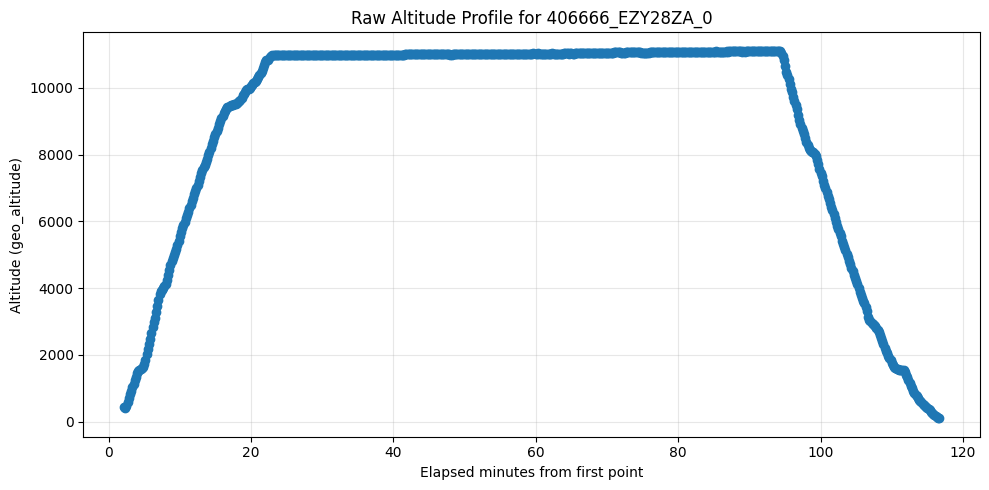

In [6]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from IPython.display import display

from src.trajectory_builder import (
    build_notebook_context,
    build_single_flight_prototype,
    choose_altitude_column,
    get_notebook_controls,
)

ctx = build_notebook_context(PROJECT_ROOT)
controls = get_notebook_controls(ctx)
result = build_single_flight_prototype(ctx, controls)

summary_cols = [
    'selected_icao24', 'selected_callsign', 'selected_reason', 'trajectory_id',
    'trajectory_quality_status', 'trajectory_quality_score', 'is_full_flight',
    'full_flight_candidates', 'prototype_status', 'trace_policy',
    'window_group_start', 'window_group_end', 'window_proxy_rows',
    'middle_gap_count', 'largest_gap_minutes', 'total_gap_minutes',
    'gap_fraction_of_flight', 'max_inter_ping_seconds', 'ping_interval_cv'
]
display(result.summary[[col for col in summary_cols if col in result.summary.columns]])
if not result.ranking.empty:
    rank_cols = [
        'trajectory_id', 'trajectory_quality_status', 'trajectory_quality_score',
        'raw_rows', 'clean_rows', 'duration_minutes', 'route_distance_km',
        'altitude_span_m', 'window_group_start', 'window_group_end',
        'middle_gap_count', 'largest_gap_minutes', 'total_gap_minutes',
        'gap_fraction_of_flight'
    ]
    display(result.ranking[[col for col in rank_cols if col in result.ranking.columns]].head(10))
else:
    print('No ranked prototype trace was produced for this sampled slice.')

if result.prototype_status == 'valid_partial_flight':
    print('No valid full-flight candidate was found, but one coherent flight trace was recovered and kept as a bridged partial trajectory.')
elif result.prototype_status == 'no_valid_full_flight':
    print('No valid full-flight candidate found in sampled slice, and no acceptable partial trajectory was selected for plotting.')

if not result.raw_segment.empty:
    raw_plot_df = result.raw_segment.sort_values('timestamp').copy()
    raw_alt_col = choose_altitude_column(raw_plot_df)

    plt.figure(figsize=(10, 5))
    plt.plot(raw_plot_df['elapsed_minutes'], raw_plot_df[raw_alt_col], marker='o', linestyle='-')
    plt.title(f"Raw Altitude Profile for {raw_plot_df['trajectory_id'].iloc[0]}")
    plt.xlabel('Elapsed minutes from first point')
    plt.ylabel(f'Altitude ({raw_alt_col})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 2.1.2 Cleaned Flight Trace
Plot the cleaned selected segment on the map and compare its altitude profile using elapsed minutes.


Selected trajectory: 406666_EZY28ZA_0
Prototype outcome: valid full flight
Clean rows written to cleaned trace: 711
Valid map points: 711
Middle gaps above threshold: 0
Largest inter-ping interval: 0.33 minutes
Total projected-gap time: 0.00 minutes
Gap fraction of flight: 0.000


Map legend: solid lines are observed ADS-B legs, dashed lines are projected links across long missing-middle gaps.


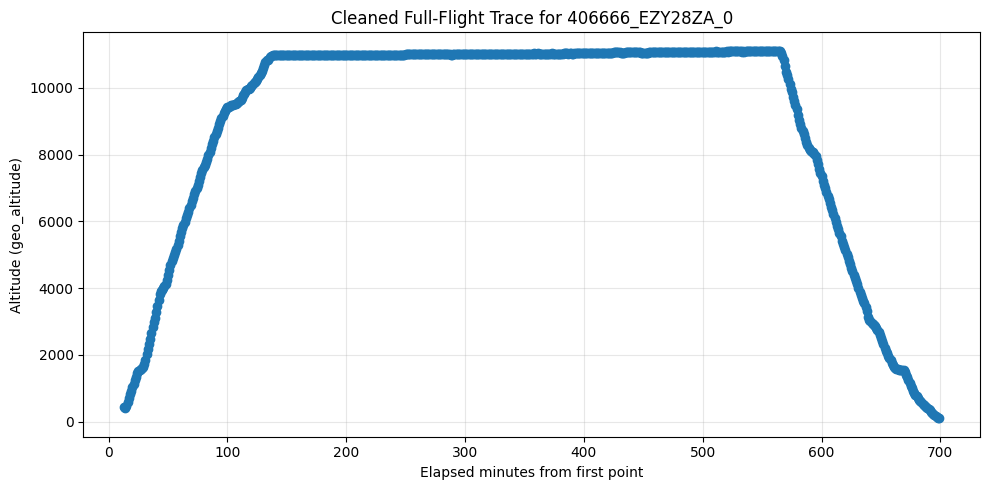

In [7]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
from IPython.display import display

from src.trajectory_builder import (
    build_notebook_context,
    build_single_flight_prototype,
    choose_altitude_column,
    get_notebook_controls,
)
from src.visualisation import TrajectoryVisualiser

ctx = build_notebook_context(PROJECT_ROOT)
controls = get_notebook_controls(ctx)
result = build_single_flight_prototype(ctx, controls)
gap_threshold_seconds = max(int(controls.max_gap_minutes * 60), 60)

if result.cleaned_segment is not None and not result.cleaned_segment.empty:
    clean_plot_df = result.cleaned_segment.sort_values('timestamp').copy()
    clean_alt_col = choose_altitude_column(clean_plot_df)
    is_partial = result.prototype_status == 'valid_partial_flight'
    status_label = 'valid partial flight' if is_partial else 'valid full flight'
    title_prefix = 'Cleaned Partial Trace' if is_partial else 'Cleaned Full-Flight Trace'

    print(f"Selected trajectory: {clean_plot_df['trajectory_id'].iloc[0]}")
    print(f'Prototype outcome: {status_label}')
    print(f'Clean rows written to cleaned trace: {len(clean_plot_df):,}')
    print(f"Valid map points: {len(clean_plot_df.dropna(subset=['latitude', 'longitude'])):,}")
    print(f"Middle gaps above threshold: {int(result.summary['middle_gap_count'].iloc[0])}")
    print(f"Largest inter-ping interval: {float(result.summary['largest_gap_minutes'].iloc[0]):.2f} minutes")
    print(f"Total projected-gap time: {float(result.summary['total_gap_minutes'].iloc[0]):.2f} minutes")
    print(f"Gap fraction of flight: {float(result.summary['gap_fraction_of_flight'].iloc[0]):.3f}")

    if len(clean_plot_df.dropna(subset=['latitude', 'longitude'])) >= 2:
        m = TrajectoryVisualiser.generate_interactive_map_with_projections(
            clean_plot_df,
            trajectory_ids=[clean_plot_df['trajectory_id'].iloc[0]],
            gap_threshold_seconds=gap_threshold_seconds,
        )
        display(m)
        print('Map legend: solid lines are observed ADS-B legs, dashed lines are projected links across long missing-middle gaps.')
    else:
        print('Not enough valid latitude/longitude points to render the cleaned route.')

    plt.figure(figsize=(10, 5))
    plt.plot(clean_plot_df['elapsed_minutes'], clean_plot_df[clean_alt_col], marker='o', linestyle='-')
    plt.title(f"{title_prefix} for {clean_plot_df['trajectory_id'].iloc[0]}")
    plt.xlabel('Elapsed minutes from first point')
    plt.ylabel(f'Altitude ({clean_alt_col})')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
elif result.prototype_status == 'no_valid_full_flight':
    print('No valid full-flight or coherent partial trajectory was found in the sampled slice. Cleaned path view is intentionally skipped.')
else:
    print('The selected prototype did not produce a cleaned trajectory to plot.')


## 2.1.3 Trajectory Quality Summary
Summarize why this cleaned segment is or is not a full takeoff-to-landing trajectory.


In [8]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display

from src.trajectory_builder import build_notebook_context, build_single_flight_prototype, get_notebook_controls

ctx = build_notebook_context(PROJECT_ROOT)
controls = get_notebook_controls(ctx)
result = build_single_flight_prototype(ctx, controls)

summary_cols = [
    'trajectory_id', 'prototype_status', 'trace_policy', 'window_group_start', 'window_group_end', 'window_proxy_rows',
    'raw_rows', 'clean_rows', 'map_rows', 'missing_timestamp_rows_removed', 'invalid_coordinate_rows_removed',
    'exact_duplicates_removed', 'stale_rows_removed', 'altitude_spikes_removed',
    'split_count', 'middle_gap_count', 'largest_gap_minutes', 'total_gap_minutes',
    'gap_fraction_of_flight', 'has_middle_gap', 'max_inter_ping_seconds',
    'median_inter_ping_seconds', 'ping_interval_cv', 'duration_minutes',
    'valid_map_points', 'route_distance_km', 'altitude_span_m', 'start_altitude_m',
    'end_altitude_m', 'starts_groundish', 'ends_groundish', 'has_sustained_climb',
    'has_sustained_descent', 'has_altitude_spike', 'is_mappable', 'is_full_flight',
    'trajectory_quality_status', 'trajectory_quality_score', 'full_flight_candidates',
    'diagnostic_fallback_used'
]
display(result.summary[[col for col in summary_cols if col in result.summary.columns]])


,trajectory_id,prototype_status,trace_policy,window_group_start,window_group_end,window_proxy_rows,raw_rows,clean_rows,map_rows,missing_timestamp_rows_removed,...,ends_groundish,has_sustained_climb,has_sustained_descent,has_altitude_spike,is_mappable,is_full_flight,trajectory_quality_status,trajectory_quality_score,full_flight_candidates,diagnostic_fallback_used
0,406666_EZY28ZA_0,valid_full_flight,bridge_middle_gaps,16,19,718,718,711,711,0,...,True,True,True,False,True,True,full_flight,1.0,1,False


## 2.2 Full-Dataset Reconstruction
Apply the same strict cleaning, splitting, and quality labeling rules to the full ADS-B dataset. This stays optional until the single-flight prototype looks right.


In [ ]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display

from src.trajectory_builder import build_notebook_context, reconstruct_full_dataset

PROJECT_ROOT = _resolve_project_root()
ctx = build_notebook_context(PROJECT_ROOT)

RUN_FULL_RECONSTRUCTION = True
BATCH_SIZE = 200_000
BATCH_MAX_GAP_MINUTES = None

if RUN_FULL_RECONSTRUCTION:
    batch_output_path, df_batch_quality = reconstruct_full_dataset(
        ctx,
        batch_size=BATCH_SIZE,
        max_gap_minutes=BATCH_MAX_GAP_MINUTES,
    )
    print(f'Wrote cleaned trajectories to {batch_output_path}')
    if df_batch_quality is not None and not df_batch_quality.empty:
        display(df_batch_quality['trajectory_quality_status'].value_counts().rename_axis('trajectory_quality_status').reset_index(name='trajectory_count'))
else:
    print('Batch reconstruction is disabled. Validate the single-flight prototype first, then set RUN_FULL_RECONSTRUCTION = True when ready.')


## 2.3 Open-Ended / Partial Flight Analysis
Summarize the quality-status distribution for the prototype segments and, when available, the batch trajectory dataset.


In [ ]:
from pathlib import Path
import sys

def _resolve_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path('.').resolve(), Path('..').resolve()]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs' / 'config.yaml').exists():
            return candidate
    raise FileNotFoundError('Could not resolve project root for notebook execution.')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import display

from src.trajectory_builder import (
    build_notebook_context,
    build_single_flight_prototype,
    get_notebook_controls,
    summarize_partial_status_from_parquet,
    summarize_prototype_segments,
)

ctx = build_notebook_context(PROJECT_ROOT)
controls = get_notebook_controls(ctx)
result = build_single_flight_prototype(ctx, controls)

prototype_status_counts = summarize_prototype_segments(result)
print('Selected prototype trace quality distribution:')
display(prototype_status_counts)

if ctx.traj_path.exists():
    try:
        full_status_counts = summarize_partial_status_from_parquet(ctx.traj_path)
        print('Batch trajectory quality distribution:')
        display(full_status_counts)
    except Exception as exc:
        print(f'Batch trajectory quality summary is not available yet: {exc}')
else:
    print(f'Full trajectory parquet not found yet: {ctx.traj_path}')


Selected prototype trace quality distribution:


,trajectory_quality_status,trajectory_count,pct
0,partial_end_missing,1,100.0


Batch trajectory quality summary is not available yet: Trajectory parquet does not include quality status columns yet. Run the batch reconstruction cell first.
